# Phase 8 - 제주 실시간 SMP(smp_rt) : 갭 진단 + 최악 회피 모델 (v2)

Phase 7(model7)은 검증(실측 피처)에서는 DA 를 이겼지만 시험(예보 피처)에서
무너졌다 (검증 MAE 8.62 -> 시험 11.11, 음수 탐지 재현 0.73 -> 0.48).

## 이번 단계에서 하는 일
1. **갭 원인 진단** : 검증=실측 피처(clean_total), 시험=예보 피처(forecast_data)
   라서 생기는 'train/serve 피처 품질 불일치'를 같은 구간에서 1:1 로 분해해
   보여준다. (과적합이 아니라 예보 오차 손해라는 것을 데이터로 확인)
2. **예보 노이즈 주입** : 겹침 구간에서 잰 예보 오차를 학습기간(실측) 이용률에
   주입해, 모델이 예보 노이즈에 강건하게 학습하도록 한다.
3. **neg_flag 분류기 + danger zone** : 가격을 정확히 못 맞혀도, 음수(<=0)가
   될 위험 구간을 그림에 표시하는 것이 실제로 쓸모 있다.
4. **비대칭 최악 회피 (v2 재설계)** : 진짜 피해야 할 최악은 '예측은 (+) 인데
   실제가 (-)'. 반대는 가볍게 본다. v1 은 음수 위험이면 무조건 깊은 음수(-67)로
   슬램해 정상구간 MAE 가 폭발했다. v2 는 **확신할 때만 깊게, 애매하면 0 근처,
   위험 띠(시각화)는 따로 공격적으로** 한다. 운영점은 **봄한낮BCD MAE 상한**을
   둔 채 비대칭비용 최소로 고른다 (한 줄 파라미터로 조절).
5. **est_demand_new 비교** : 새 수요추정치로 net_load 가 좋아지면 봄한낮 MAE 가
   줄어드는지 old vs new 로 직접 비교한다.

> 분할은 model7 과 동일. 학습 2024-03-01~2026-01-31(실측), 검증
> 2026-02-01~2026-05-13(실측), 시험 forecast_data 전체(예보).
> forecast_data 가 검증 구간과 거의 겹치므로 같은 시각에서 실측 vs 예보를
> 직접 비교할 수 있다 (갭 진단의 핵심).

In [1]:
# ── 라이브러리 + 한글 폰트 ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import holidays as hd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, brier_score_loss



import matplotlib.font_manager as fm
import platform
from matplotlib import font_manager, rc

# 1. 마이너스 기호 깨짐 방지를 최상단에 먼저 설정
plt.rcParams['axes.unicode_minus'] = False

# 2. 운영체제에 따른 폰트 설정
if platform.system() == 'Windows':
    # 맑은 고딕을 인식할 수 있도록 시스템 이름과 영문 이름을 모두 리스트로 지정
    rc('font', family=['Malgun Gothic', 'sans-serif'])




RNG = 42  # 재현용 고정 시드
print("라이브러리 준비 완료")

라이브러리 준비 완료


In [2]:
# ── 데이터 불러오기 ────────────────────────────────────────────────────
# clean_total: 실측 피처(cp949) / clean_rt_smp: 타깃 / forecast_data: 예보(utf-8)
feat = pd.read_csv("clean_total.csv", index_col="timestamp",
                   parse_dates=True, encoding="cp949").sort_index()
rt = pd.read_csv("clean_rt_smp.csv", index_col="timestamp",
                 parse_dates=True).sort_index()
fc = pd.read_csv("forecast_data.csv", index_col="timestamp",
                 parse_dates=True).sort_index()

target = rt["smp_rt_hourly_mean"].rename("smp_rt")  # 타깃 = 시간별 실시간 SMP
df = feat.join(target, how="inner")                 # 학습/검증용 (실측+타깃)

print(f"clean_total : {feat.index.min()} ~ {feat.index.max()}  ({len(feat)}행)")
print(f"forecast    : {fc.index.min()} ~ {fc.index.max()}  ({len(fc)}행)")
print(f"학습/검증용 : {df.index.min()} ~ {df.index.max()}  ({len(df)}행)")
print(f"음수(smp_rt<=0) 비율: {(df['smp_rt'] <= 0).mean():.1%} | "
      f"바닥(smp_rt<5) 비율: {(df['smp_rt'] < 5).mean():.1%}")

clean_total : 2020-01-01 00:00:00 ~ 2026-05-13 23:00:00  (55800행)
forecast    : 2026-01-31 00:00:00 ~ 2026-05-17 23:00:00  (2568행)
학습/검증용 : 2024-03-01 00:00:00 ~ 2026-05-13 23:00:00  (19296행)
음수(smp_rt<=0) 비율: 3.1% | 바닥(smp_rt<5) 비율: 3.2%


## 피처 빌드 (model7 구조 그대로)

model7 의 `build_features` 를 그대로 쓴다. 풍력 엔지니어링/출력제어 EDA 는
프로젝트를 복잡하게 만들어 제거했다 - model7 의 풍력 피처(`Wind_Utilization`,
`wind_spd`, `wind_spd_north`, `wd_*`)만 유지한다.

학습(clean_total)과 시험(forecast_data)에 **공통으로 있는 컬럼만** 써야 시험
에서 그대로 돈다 (`assert_parity` 로 강제). 누수 재정의(사용자 지침): 미래
예보/lead 는 미리 알 수 있으니 정당한 입력. 진짜 누수는 **같은 시각 타깃
자신**뿐. `real_*`/`supply_cap` 은 예보 파일에 없으니 serve 불가 -> 제외.

In [3]:
# ── 공통 피처 빌더 (학습/시험 같은 코드 경로) ──────────────────────────
NL_CUTS = [181.3, 264.5, 383.6]  # Phase 5 구간 D<181.3<=C<264.5<=B<383.6<=A

FEATURE_COLS = [
    # 하루전 가격 (예보로 안 망가지는 깨끗한 입력)
    "smp_jeju", "smp_land", "da_anchor",
    "da_neg", "da_low", "da_gap5", "land_neg",
    # net_load 및 미래 net_load (Phase 6 핵심 신호)
    "net_load", "nl_lead_1", "nl_lead_2", "nl_lead_3",
    "nl_lead_6", "nl_lead_12", "nl_lead_24",
    "nl_fwdmin_6", "nl_fwdmin_12", "nl_delta_1", "nl_lead_delta_2",
    "is_zoneA", "zone_code",
    # 태양광 / 풍력 (model7 그대로)
    "solar_rad", "total_cloud", "midlow_cloud", "Solar_Utilization",
    "Wind_Utilization", "wind_spd", "wind_spd_north",
    "wd_sin", "wd_cos", "wd_sin_north", "wd_cos_north",
    # 날씨 파생
    "temp_c", "humidity", "rainfall", "hdd", "cdd",
    # 달력 / 구간 (실측이든 예보든 동일)
    "hour", "dow", "month", "is_weekend", "is_holiday",
    "spring_midday", "is_market_pretest",
]

# 예보로 품질이 망가지는(=예보-실측 차이가 큰) 피처군. Part 0 에서 쓴다.
RENEW_DERIVED = ["net_load", "nl_lead_1", "nl_lead_2", "nl_lead_3",
                 "nl_lead_6", "nl_lead_12", "nl_lead_24", "nl_fwdmin_6",
                 "nl_fwdmin_12", "nl_delta_1", "nl_lead_delta_2",
                 "Solar_Utilization", "Wind_Utilization"]


def build_features(src, mode):
    """clean_total(mode='train') 와 forecast_data(mode='serve') 를
    똑같은 피처 집합으로 만든다."""
    d = src.copy()

    # 1) 이용률 컬럼 이름 통일 (예보는 est_ 접두사) + 예보 결측 보정
    if mode == "serve":
        d = d.rename(columns={"est_Solar_Utilization": "Solar_Utilization",
                              "est_Wind_Utilization": "Wind_Utilization"})
        num = d.select_dtypes(include="number").columns
        d[num] = d[num].interpolate(limit_direction="both").ffill().bfill()

    # 2) net_load (두 파일 동일 식)
    solar_mw = d["Solar_Utilization"] * d["Solar_Capacity_Est"]
    wind_mw = d["Wind_Utilization"] * d["Wind_Capacity_Est"]
    d["net_load"] = d["est_demand"] - (solar_mw + wind_mw)

    # 3) 구간 코드 (A/B/C/D)
    nl = d["net_load"]
    d["zone_code"] = np.select(
        [nl < NL_CUTS[0], nl < NL_CUTS[1], nl < NL_CUTS[2]],
        [0, 1, 2], default=3)
    d["is_zoneA"] = (d["zone_code"] == 3).astype(int)

    # 4) 미래 net_load (Phase 6 핵심 신호)
    for h in [1, 2, 3, 6, 12, 24]:
        d[f"nl_lead_{h}"] = nl.shift(-h)
    rev = nl[::-1]
    d["nl_fwdmin_6"] = rev.rolling(6, min_periods=1).min()[::-1]
    d["nl_fwdmin_12"] = rev.rolling(12, min_periods=1).min()[::-1]
    d["nl_delta_1"] = nl - nl.shift(1)
    d["nl_lead_delta_2"] = d["nl_lead_2"] - nl

    # 5) 하루전 기준값 + DA 자체 바닥 신호 (Phase 3)
    d["da_anchor"] = 24.94 + 0.754 * d["smp_jeju"]
    d["da_neg"] = (d["smp_jeju"] < 0).astype(int)
    d["da_low"] = (d["smp_jeju"] < 5).astype(int)
    d["da_gap5"] = np.maximum(0.0, 5.0 - d["smp_jeju"])
    d["land_neg"] = (d["smp_land"] < 0).astype(int)

    # 6) 날씨 파생
    d["hdd"] = np.maximum(0.0, 18.0 - d["temp_c"])
    d["cdd"] = np.maximum(0.0, d["temp_c"] - 26.0)

    # 7) 달력 - timestamp 에서 다시 계산 (시험 파일도 자체 동작)
    yrs = range(d.index.year.min(), d.index.year.max() + 1)
    kr = hd.KR(years=yrs)
    d["hour"] = d.index.hour
    d["dow"] = d.index.dayofweek
    d["month"] = d.index.month
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    d["is_holiday"] = pd.Series(d.index.normalize(),
                                index=d.index).isin(set(kr)).astype(int)
    d["spring_midday"] = (d["month"].between(3, 5)
                          & d["hour"].between(10, 13)).astype(int)
    d["is_market_pretest"] = (d.index < pd.Timestamp("2024-06-01")).astype(int)
    # 주의: 학습 2024-06-01~ 이면 이 값은 어디서나 상수 0 이다.
    # 피처 정합성과 전체데이터본과의 1:1 비교를 위해 컬럼은 그대로 둔다(트리는 무시).
    return d


def assert_parity(a, b):
    assert list(a.columns) == list(b.columns), "피처 컬럼/순서 불일치!"
    print(f"정합성 통과: {len(a.columns)}개 피처가 학습/시험 동일")


print(f"피처 {len(FEATURE_COLS)}개 정의 (model7 구조)")

피처 43개 정의 (model7 구조)


In [4]:
# ── 분할 + 겹침(검증) 구간 정렬 ────────────────────────────────────────
# [데이터 구간 규칙] 과제 규칙상 제주 시범사업('24.6.1) 이후 데이터만 사용한다.
# 그래서 학습 시작을 2024-06-01 로 둔다. (구 2024-03-01 전체데이터본 결과는
# 보고서의 '데이터 구간 민감도 비교' 절에 별도로 보존해 비교용으로만 쓴다.)
TRAIN_START = pd.Timestamp("2024-06-01")
TRAIN_END = pd.Timestamp("2026-01-31 23:00")
VAL_START = pd.Timestamp("2026-02-01")
VAL_END = pd.Timestamp("2026-05-13 23:00")

# lead 가 분할 경계를 넘어 정상 계산되도록 전체에서 만든 뒤 자른다
full = build_features(df, mode="train")
full["smp_rt"] = df["smp_rt"]
full = full.dropna(subset=FEATURE_COLS + ["smp_rt"])
train = full.loc[TRAIN_START:TRAIN_END]
val = full.loc[VAL_START:VAL_END]                       # 검증(실측 피처)

# 시험(예보 피처) + 같은 검증구간의 예보 피처(갭 진단용)
fc_full = build_features(fc, mode="serve")
fc_full = fc_full.join(target, how="left")
test = fc_full.dropna(subset=FEATURE_COLS)              # 시험(예보 피처)
val_fc = fc_full.loc[VAL_START:VAL_END].dropna(subset=FEATURE_COLS)

# 검증구간에서 실측 vs 예보가 모두 있는 '같은 시각'만 (1:1 비교용)
common = val.index.intersection(val_fc.index)
val_a = val.loc[common]                                 # 같은 시각, 실측 피처
val_f = val_fc.loc[common]                              # 같은 시각, 예보 피처

assert_parity(train[FEATURE_COLS], test[FEATURE_COLS])
for nm, d in [("학습", train), ("검증(실측)", val),
              ("검증겹침", val_a), ("시험(예보)", test)]:
    hy = d["smp_rt"].notna()
    print(f"{nm:9s}: {len(d):5d}행 | 타깃 {int(hy.sum()):5d} | "
          f"음수<=0 {int((d['smp_rt'] <= 0).sum()):4d} | "
          f"{d.index.min()} ~ {d.index.max()}")

정합성 통과: 43개 피처가 학습/시험 동일
학습       : 14640행 | 타깃 14640 | 음수<=0  279 | 2024-06-01 00:00:00 ~ 2026-01-31 23:00:00
검증(실측)   :  2424행 | 타깃  2424 | 음수<=0  124 | 2026-02-01 00:00:00 ~ 2026-05-12 23:00:00
검증겹침     :  2424행 | 타깃  2424 | 음수<=0  124 | 2026-02-01 00:00:00 ~ 2026-05-12 23:00:00
시험(예보)   :  2543행 | 타깃  2495 | 음수<=0  127 | 2026-01-31 01:00:00 ~ 2026-05-16 23:00:00


C:\Users\bjkim\AppData\Local\Temp\ipykernel_15216\1477831558.py:83: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  index=d.index).isin(set(kr)).astype(int)
C:\Users\bjkim\AppData\Local\Temp\ipykernel_15216\1477831558.py:83: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  index=d.index).isin(set(kr)).astype(int)


## 기본 모델 (model7 구조, 실측 학습 - 갭 진단 probe 용)

회귀 구조는 model7 을 유지한다. 갭을 분해해 보이려면 model7 과 같은 모델이
먼저 있어야 하므로 실측 학습으로 한 번 적합한다. (여기 probe 는 OOF/보정/밴드
없는 단순 합치기라 MAE 자체는 운영 모델보다 높다 - 상대 비교용. 운영 모델은
Part 1 에서 예보 노이즈를 주입해 다시 학습한다.)

In [5]:
# ── 기본 모델: 바닥 분류기 + 잔차 회귀 (실측 학습, 진단용) ──────────────
FLOOR_VAL = float(train.loc[train["smp_rt"] < 5, "smp_rt"].median())
DEEP_NEG = float(train.loc[train["smp_rt"] <= 0, "smp_rt"].median())
print(f"바닥값(중앙값)={FLOOR_VAL:.2f} | 깊은음수값(중앙값)={DEEP_NEG:.2f}")


def make_clf(spw):
    return lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.03, num_leaves=31, max_depth=5,
        min_child_samples=60, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=RNG, n_jobs=-1, verbose=-1)


def make_reg(objective, alpha=None):
    return lgb.LGBMRegressor(
        objective=objective, alpha=alpha,
        n_estimators=800, learning_rate=0.03, num_leaves=31, max_depth=5,
        min_child_samples=60, subsample=0.8, colsample_bytree=0.8,
        random_state=RNG, n_jobs=-1, verbose=-1)


def fit_base(tr):
    y1 = (tr["smp_rt"] < 5).astype(int)
    spw = (y1 == 0).sum() / max((y1 == 1).sum(), 1)
    clf = make_clf(spw).fit(tr[FEATURE_COLS], y1)
    nf = tr[tr["smp_rt"] >= 5]
    reg = make_reg("l2").fit(nf[FEATURE_COLS],
                             nf["smp_rt"] - nf["da_anchor"])
    return clf, reg


def predict_simple(clf, reg, d, tau=0.30):
    p = clf.predict_proba(d[FEATURE_COLS])[:, 1]
    lvl = d["da_anchor"].values + reg.predict(d[FEATURE_COLS])
    yhat = np.where(p >= tau, FLOOR_VAL, lvl)
    yhat = np.where(d["is_zoneA"].values == 1, d["smp_jeju"].values, yhat)
    return yhat


clf0, reg0 = fit_base(train)
print("기본 모델 적합 완료 (실측 학습)")

바닥값(중앙값)=-69.76 | 깊은음수값(중앙값)=-69.76
기본 모델 적합 완료 (실측 학습)


## Part 0 - 갭 원인 진단 : 실측 vs 예보 (같은 시각, 1:1)

**질문**: model7 의 검증(8.62) -> 시험(11.11) 갭은 과적합인가, 예보 오차인가?

**방법**: 검증 구간의 *같은 시각*에 (a) 실측 피처 (b) 예보 피처를 같은 모델에
넣는다. 타깃 동일 -> 차이는 오직 '피처 품질'. 그다음 피처를 **출처별 그룹**
으로 나눠 한 그룹씩 실측->예보로 바꿔 끼우며 MAE 증가(=그 그룹의 갭 기여)를
본다. (단일그룹 합은 전체 갭보다 작다 - 그룹 간 상호작용 때문. 어느 그룹이
'가장 큰 단일 기여'인지를 본다.)

같은 시각 2424행 | 실측피처 MAE=10.57 -> 예보피처 MAE=12.57  (전체 예보오차 손해 = +1.99)
봄한낮BCD : 실측 52.83 -> 예보 61.67

[그룹별 갭 기여] (실측->예보 한 그룹만 바꿨을 때 MAE 증가)
       피처수  MAE증가
그룹               
신재생파생   13   2.82
날씨예보    14   0.00
DA       7   0.00
달력       9   0.06


C:\Users\bjkim\AppData\Local\Temp\ipykernel_15216\2959901711.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([err[:, i] for i in range(len(key))], labels=key,


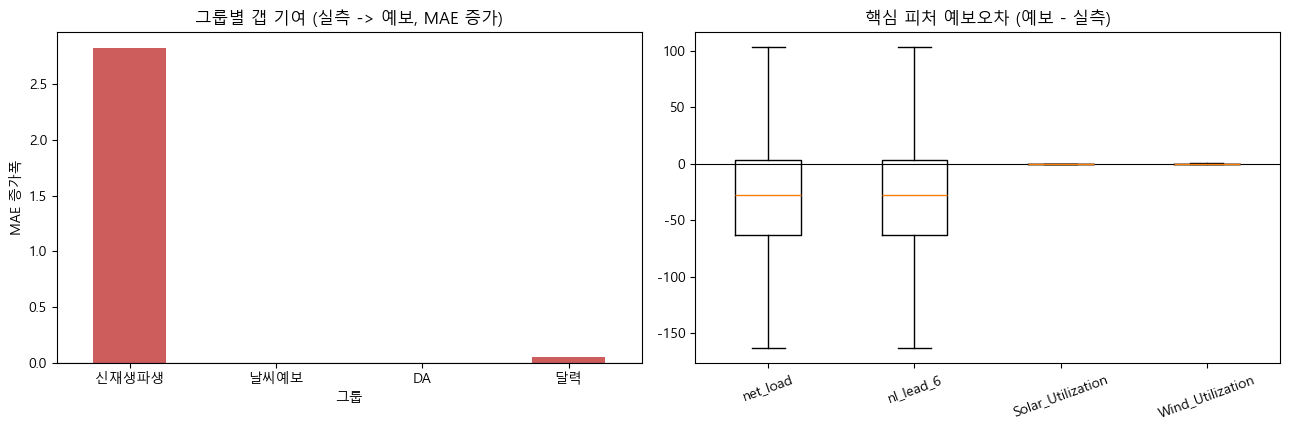

In [6]:
# ── Part 0: 같은 시각 실측 vs 예보 + 그룹 스왑 분해 ─────────────────────
m = val_a["smp_rt"].notna() & val_f["smp_rt"].notna()
ya = val_a.loc[m, "smp_rt"].values
sm = (val_a.loc[m, "spring_midday"].values == 1) \
     & (val_a.loc[m, "is_zoneA"].values == 0)          # 봄한낮 BCD

mae = lambda yh: float(np.mean(np.abs(yh - ya)))
yh_act = predict_simple(clf0, reg0, val_a.loc[m])      # 전부 실측
yh_fc = predict_simple(clf0, reg0, val_f.loc[m])       # 전부 예보
mae_act, mae_fc = mae(yh_act), mae(yh_fc)

G_da = ["smp_jeju", "smp_land", "da_anchor", "da_neg", "da_low",
        "da_gap5", "land_neg"]
G_cal = ["is_zoneA", "zone_code", "hour", "dow", "month", "is_weekend",
         "is_holiday", "spring_midday", "is_market_pretest"]
G_wx = ["solar_rad", "total_cloud", "midlow_cloud", "wind_spd",
        "wind_spd_north", "wd_sin", "wd_cos", "wd_sin_north",
        "wd_cos_north", "temp_c", "humidity", "rainfall", "hdd", "cdd"]
G_renew = [c for c in FEATURE_COLS
           if c not in G_da + G_cal + G_wx]             # 신재생파생

rows = []
for gname, g in [("신재생파생", G_renew), ("날씨예보", G_wx),
                 ("DA", G_da), ("달력", G_cal)]:
    mix = val_a.loc[m].copy()
    mix[g] = val_f.loc[m, g].values                     # 이 그룹만 예보로
    e = mae(predict_simple(clf0, reg0, mix)) - mae_act
    rows.append((gname, len(g), e))
gap_tbl = pd.DataFrame(rows, columns=["그룹", "피처수", "MAE증가"]) \
    .set_index("그룹")

print(f"같은 시각 {int(m.sum())}행 | 실측피처 MAE={mae_act:.2f} -> "
      f"예보피처 MAE={mae_fc:.2f}  (전체 예보오차 손해 = {mae_fc - mae_act:+.2f})")

#print(f"봄한낮BCD : 실측 {mae(yh_act[sm]):.2f} -> 예보 {mae(yh_fc[sm]):.2f}")
print(f"봄한낮BCD : 실측 {float(np.mean(np.abs(yh_act[sm] - ya[sm]))):.2f} -> 예보 {float(np.mean(np.abs(yh_fc[sm] - ya[sm]))):.2f}")
print("\n[그룹별 갭 기여] (실측->예보 한 그룹만 바꿨을 때 MAE 증가)")
print(gap_tbl.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
gap_tbl["MAE증가"].plot.bar(ax=ax[0], color="indianred")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_title("그룹별 갭 기여 (실측 -> 예보, MAE 증가)")
ax[0].set_ylabel("MAE 증가폭")
ax[0].tick_params(axis="x", rotation=0)

key = ["net_load", "nl_lead_6", "Solar_Utilization", "Wind_Utilization"]
err = (val_f.loc[m, key].values - val_a.loc[m, key].values)
ax[1].boxplot([err[:, i] for i in range(len(key))], labels=key,
              showfliers=False)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("핵심 피처 예보오차 (예보 - 실측)")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 보고 (Part 0 갭 진단)

> 아래는 위 그림을 글로 옮긴 것. (수치는 실행 후 사용자가 확인)

- 같은 시각·같은 타깃인데 **실측 -> 예보 피처로만 바꿔도 MAE 가 오른다**
  => 갭은 과적합이 아니라 **예보 오차 손해**. model7 검증->시험 갭의 정체.
- 그룹별로 **신재생파생(net_load/미래net_load/태양광·풍력이용률)** 이 가장 큰
  단일 기여. DA 는 ~0 (예보여도 깨끗), 달력도 거의 0. (단일그룹 합이 전체보다
  작은 건 그룹 상호작용 때문 - 전부 예보로 바꾼 값이 진짜 상한.)
- 핵심 피처 예보오차 박스플롯에서 net_load/미래net_load 오차폭이 크고
  **봄 한낮**에서 더 벌어진다.
- 결론: 고칠 지점은 모델 복잡도가 아니라 **예보 노이즈에 강건 학습** + **깨끗한
  DA 의존** + (가능하면) **더 좋은 수요추정**(Part 4 의 est_demand_new).

## Part 1 - 예보 노이즈 주입 후 강건 재학습

겹침 구간에서 잰 **예보 오차(예보 - 실측)** 를 태양광·풍력 *이용률* 에 주입한
'노이즈 학습셋'을 만든다. 이용률에 주입하면 `build_features` 를 통해
net_load·미래net_load 까지 예보처럼 흐트러진다. 모델이 이 노이즈 위에서
학습하면 검증(실측)->시험(예보) 전이가 좋아진다. 운영 모델은 여기서 만든다
(노이즈 학습셋 + 롤링 OOF + isotonic 보정, model7 방식).

In [7]:
# ── Part 1: 예보오차 표본(시각별) -> 학습셋 주입 ───────────────────────
mm = val_a.index.intersection(val_f.index)
res_solar = (val_f.loc[mm, "Solar_Utilization"]
             - val_a.loc[mm, "Solar_Utilization"])
res_wind = (val_f.loc[mm, "Wind_Utilization"]
            - val_a.loc[mm, "Wind_Utilization"])
hours_ref = val_a.loc[mm].index.hour
bank = {h: {"s": res_solar.values[hours_ref == h],
            "w": res_wind.values[hours_ref == h]} for h in range(24)}
rs = np.random.RandomState(RNG)


def inject_noise(src):
    """학습용 src(실측)의 태양광/풍력 이용률에 시각별 예보오차를 더한다."""
    d = src.copy()
    h = d.index.hour
    for col, key, lo, hi in [("Solar_Utilization", "s", 0.0, 1.0),
                             ("Wind_Utilization", "w", 0.0, 1.5)]:
        add = np.zeros(len(d))
        for hh in range(24):
            idx = np.where(h == hh)[0]
            pool = bank[hh][key]
            if len(idx) and len(pool):
                add[idx] = rs.choice(pool, size=len(idx), replace=True)
        d[col] = np.clip(d[col].values + add, lo, hi)
    return d


df_noisy = df.copy()
inj = inject_noise(df_noisy[["Solar_Utilization", "Wind_Utilization"]])
df_noisy["Solar_Utilization"] = inj["Solar_Utilization"]
df_noisy["Wind_Utilization"] = inj["Wind_Utilization"]
full_n = build_features(df_noisy, mode="train")
full_n["smp_rt"] = df_noisy["smp_rt"]
full_n = full_n.dropna(subset=FEATURE_COLS + ["smp_rt"])
train_n = full_n.loc[TRAIN_START:TRAIN_END]
print(f"노이즈 학습셋 {len(train_n)}행 (태양광/풍력 이용률에 예보오차 주입)")

노이즈 학습셋 14640행 (태양광/풍력 이용률에 예보오차 주입)


C:\Users\bjkim\AppData\Local\Temp\ipykernel_15216\1477831558.py:83: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  index=d.index).isin(set(kr)).astype(int)


In [8]:
# ── Part 1: 운영 모델 = 롤링 OOF + isotonic (노이즈 학습셋) ────────────
CUTS = [pd.Timestamp(x) for x in
        ["2024-09-01", "2025-01-01", "2025-04-01",
         "2025-07-01", "2025-10-01", "2026-01-01"]]
segs = list(zip(CUTS, CUTS[1:] + [TRAIN_END + pd.Timedelta("1h")]))


def fit_calibrated(tr, ycol_fn, label):
    """시간순 확장폴드 OOF -> isotonic 보정 -> 전체 재적합한 분류기."""
    y = ycol_fn(tr).astype(int)
    oof = pd.Series(np.nan, index=tr.index)
    for s, e in segs:
        a = tr.loc[:s - pd.Timedelta("1h")]
        b = tr.loc[s:e - pd.Timedelta("1h")]
        if len(a) < 200 or len(b) == 0:
            continue
        ya = ycol_fn(a).astype(int)
        spw = (ya == 0).sum() / max((ya == 1).sum(), 1)
        mdl = make_clf(spw).fit(a[FEATURE_COLS], ya)
        oof.loc[b.index] = mdl.predict_proba(b[FEATURE_COLS])[:, 1]
    ok = oof.notna()
    iso = IsotonicRegression(out_of_bounds="clip").fit(oof[ok], y[ok])
    spw = (y == 0).sum() / max((y == 1).sum(), 1)
    clf = make_clf(spw).fit(tr[FEATURE_COLS], y)
    ap = average_precision_score(y[ok], iso.predict(oof[ok]))
    print(f"  [{label}] OOF PR-AUC={ap:.3f} "
          f"(양성 {int(y[ok].sum())}/{int(ok.sum())})")
    return lambda X: iso.predict(clf.predict_proba(X)[:, 1])


print("운영 모델 학습 (노이즈 학습셋)")
floor_proba = fit_calibrated(train_n, lambda d: d["smp_rt"] < 5, "바닥<5")
neg_proba = fit_calibrated(train_n, lambda d: d["smp_rt"] <= 0, "음수<=0")

nf = train_n[train_n["smp_rt"] >= 5]
y2 = nf["smp_rt"] - nf["da_anchor"]
reg = make_reg("l2").fit(nf[FEATURE_COLS], y2)
reg_q = {a: make_reg("quantile", alpha=a).fit(nf[FEATURE_COLS], y2)
         for a in (0.1, 0.9)}
print("잔차 회귀 + 분위(10/90%) 적합 완료")

운영 모델 학습 (노이즈 학습셋)
  [바닥<5] OOF PR-AUC=0.380 (양성 262/12432)
  [음수<=0] OOF PR-AUC=0.363 (양성 259/12432)
잔차 회귀 + 분위(10/90%) 적합 완료


## Part 2 - neg_flag 분류기 (danger zone 의 동력)

`neg_proba` = 그 시각이 음수(<=0)일 보정 확률. 가격을 정확히 못 맞혀도
**음수 위험을 미리 표시**하면 운영에 쓸모 있다 (사용자 핵심 목표).
검증(예보 피처)에서 분류기가 음수를 잘 분리하는지 본다.

검증(예보) 음수 PR-AUC=0.626 | Brier=0.0293 | 실제 음수 124/2448


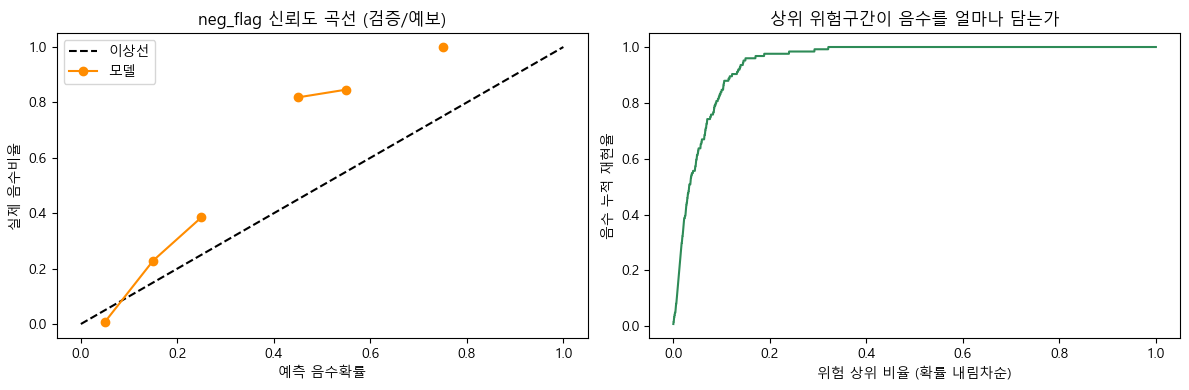

In [9]:
# ── Part 2: neg_flag 분류기 신뢰도 (검증, 예보 피처) ──────────────────
vy = val_fc["smp_rt"].notna()
yn = (val_fc.loc[vy, "smp_rt"] <= 0).astype(int).values
pn = neg_proba(val_fc.loc[vy, FEATURE_COLS])
print(f"검증(예보) 음수 PR-AUC={average_precision_score(yn, pn):.3f} | "
      f"Brier={brier_score_loss(yn, pn):.4f} | "
      f"실제 음수 {int(yn.sum())}/{len(yn)}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1, 11)
bi = np.clip(np.digitize(pn, bins) - 1, 0, 9)
obs = [yn[bi == b].mean() if (bi == b).any() else np.nan for b in range(10)]
ax[0].plot([0, 1], [0, 1], "k--", label="이상선")
ax[0].plot(bins[:-1] + 0.05, obs, "o-", color="darkorange", label="모델")
ax[0].set_xlabel("예측 음수확률"); ax[0].set_ylabel("실제 음수비율")
ax[0].set_title("neg_flag 신뢰도 곡선 (검증/예보)"); ax[0].legend()

order = np.argsort(-pn)
cum_rec = np.cumsum(yn[order]) / max(yn.sum(), 1)
ax[1].plot(np.arange(1, len(order) + 1) / len(order), cum_rec,
           color="seagreen")
ax[1].set_xlabel("위험 상위 비율 (확률 내림차순)")
ax[1].set_ylabel("음수 누적 재현율")
ax[1].set_title("상위 위험구간이 음수를 얼마나 담는가")
plt.tight_layout()
plt.show()

### 보고 (Part 2 neg_flag)

- 신뢰도 곡선이 대각선에 붙으면 보정 양호. 예보 피처에서도 음수가 분리되면
  danger zone 으로 쓸 수 있다.
- 누적 재현 곡선이 왼쪽에서 가파르면 **위험 상위 소수 구간만 봐도 음수의
  대부분을 잡는다** -> danger zone 경보의 근거.

## Part 3 - 비대칭 최악 회피 (v2 재설계) + 운영점 선택

**v1 의 문제**: 음수확률이 조금만 높아도 깊은 음수(-67)로 슬램 -> 정상구간
false 슬램이 MAE 를 죽임 (일반 MAE DA 의 3배, 봄한낮BCD 2배).

**v2 핵심**: 치명(예측+ 실제-) 회피에 필요한 건 `예측<=0` 이지 -67 이 아니다.

- `pn >= TAU_HARD` (확신) -> 깊은 음수(DEEP_NEG). *진짜 깊은 음수*만 잡는다.
- `TAU_SOFT <= pn < TAU_HARD` (애매) -> **0** (치명은 피하되 false 슬램
  MAE 폭발 방지). 실제 +120 일 때 0 예측이면 손해 120, -67 이면 187.
- `pn < TAU_SOFT` -> 일반 수준(da_anchor + 잔차) / 바닥 / DA 밴드.
- **danger zone 띠(시각화)는 점예측과 분리** : `pn >= TAU_SOFT` 면 위험으로
  '표시'한다 (재현 높게). 가격은 못 맞혀도 위험 경보는 잘 한다 = 사용자 목표.

**운영점 선택**: 비대칭비용 최소를 찾되 **봄한낮BCD MAE <= SPRING_CAP x
DA(봄한낮BCD)** 라는 상한 제약을 둔다. `W_BAD`, `SPRING_CAP` 은 한 줄
파라미터. 스윕표에 봄한낮BCD MAE·일반 MAE·음수재현을 같이 찍어 보고 고른다.
선택은 **검증(예보 피처)** 에서 한다 (시험 전이를 위해 반드시 예보 품질에서).

봄한낮BCD: DA MAE=45.2 -> 상한 1.2x = 54.3
선택 운영점(검증/예보): TAU_SOFT=0.16 TAU_HARD=0.25 | 비용=16.49 | 봄한낮BCD MAE=46.5 | 상한충족=True

[W_BAD 스윕] (검증/예보, 봄한낮BCD 상한 적용)
       soft  hard  치명  MAE전체  봄한낮BCD_MAE  일반MAE  음수재현
W_BAD                                                
1      0.16  0.25  33  10.48        46.5   8.07  0.73
2      0.16  0.25  33  10.48        46.5   8.07  0.73
3      0.16  0.25  33  10.48        46.5   8.07  0.73
5      0.16  0.25  33  10.48        46.5   8.07  0.73
8      0.16  0.25  33  10.48        46.5   8.07  0.73
12     0.16  0.25  33  10.48        46.5   8.07  0.73
20     0.16  0.25  33  10.48        46.5   8.07  0.73


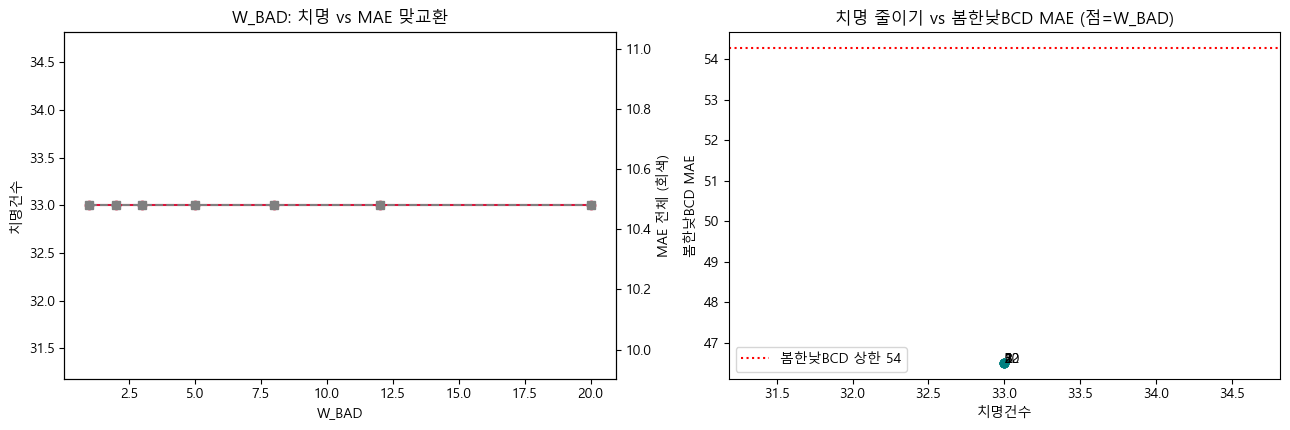

In [10]:
# ── Part 3: 비대칭 비용 + 2단 임계 합치기 ──────────────────────────────
# ===== 확정 하이퍼파라미터 (Phase 8 최종) =====
W_BAD = 5.0      # 치명(예측+ 실제-) 가중   (스윕상 >=2 동일 운영점 = 견고)
W_OK = 0.3       # 가벼움(예측- 실제+) 가중
SPRING_CAP = 1.2  # 봄한낮BCD MAE 상한 배수 (DA 대비) - 확정값
TAU_HI, TAU_LO = 0.30, 0.05   # 바닥 분류 밴드 (model7 안정값 고정)


def worst_cost(y, yhat, w_bad=None):
    w_bad = W_BAD if w_bad is None else w_bad
    e = np.abs(yhat - y)
    w = np.ones_like(e, dtype=float)
    w[(yhat > 0) & (y <= 0)] = w_bad      # 치명
    w[(yhat <= 0) & (y > 0)] = W_OK       # 가벼움
    return float(np.mean(w * e))


def n_cat(y, yhat):
    return int(np.sum((yhat > 0) & (y <= 0)))   # 양수예측인데 실제음수


def combine(d, tau_soft, tau_hard):
    """2단 음수 임계 + 바닥밴드 + A구간 passthrough.
    danger 는 시각화용(점예측과 분리, pn>=tau_soft)."""
    pn = neg_proba(d[FEATURE_COLS])
    pf = floor_proba(d[FEATURE_COLS])
    lvl = d["da_anchor"].values + reg.predict(d[FEATURE_COLS])
    da = d["smp_jeju"].values
    yhat = lvl.copy()
    yhat = np.where(pf >= TAU_HI, FLOOR_VAL, yhat)
    inb = (pf >= TAU_LO) & (pf < TAU_HI)
    yhat = np.where(inb, da, yhat)                     # 바닥 애매 -> DA 후퇴
    yhat = np.where(pn >= tau_soft, 0.0, yhat)         # 음수 애매 -> 0
    yhat = np.where(pn >= tau_hard, DEEP_NEG, yhat)    # 음수 확신 -> 깊은 음수
    yhat = np.where(d["is_zoneA"].values == 1, da, yhat)
    danger = pn >= tau_soft                            # 시각화용 띠
    return yhat, pn, pf, danger


# 검증(예보)에서 운영점 선택: 봄한낮BCD MAE 상한 안에서 비대칭비용 최소
sel = val_fc[val_fc["smp_rt"].notna()]
ys = sel["smp_rt"].values
spm = (sel["spring_midday"].values == 1) & (sel["is_zoneA"].values == 0)
da_sp = float(np.mean(np.abs(sel["smp_jeju"].values[spm] - ys[spm])))
SP_LIMIT = SPRING_CAP * da_sp
print(f"봄한낮BCD: DA MAE={da_sp:.1f} -> 상한 {SPRING_CAP}x = {SP_LIMIT:.1f}")


def pick(w_bad):
    """제약(봄한낮BCD MAE<=상한) 만족 중 비대칭비용 최소. 없으면 최소 위반."""
    grid_s = np.round(np.arange(0.04, 0.51, 0.02), 2)
    grid_h = np.round(np.arange(0.10, 0.86, 0.05), 2)
    feas, infeas = None, None
    for ts in grid_s:
        for th in grid_h:
            if th < ts:
                continue
            yh, _, _, _ = combine(sel, ts, th)
            c = worst_cost(ys, yh, w_bad)
            sp = float(np.mean(np.abs(yh[spm] - ys[spm])))
            if sp <= SP_LIMIT:
                if feas is None or c < feas[0]:
                    feas = (c, ts, th, sp)
            if infeas is None or sp < infeas[0]:
                infeas = (sp, ts, th, c)
    if feas is not None:
        return feas[1], feas[2], feas[0], feas[3], True
    return infeas[1], infeas[2], infeas[3], infeas[0], False


TAU_SOFT, TAU_HARD, c_sel, sp_sel, ok = pick(W_BAD)
print(f"선택 운영점(검증/예보): TAU_SOFT={TAU_SOFT} TAU_HARD={TAU_HARD} "
      f"| 비용={c_sel:.2f} | 봄한낮BCD MAE={sp_sel:.1f} "
      f"| 상한충족={ok}")

# W_BAD 스윕: 봄한낮BCD MAE/일반 MAE/음수재현 같이 본다
sw = []
for wb in [1, 2, 3, 5, 8, 12, 20]:
    ts, th, _, _, _ = pick(wb)
    yh, _, _, _ = combine(sel, ts, th)
    rec = ((yh <= 0) & (ys <= 0)).sum() / max(int((ys <= 0).sum()), 1)
    norm = ys >= 5
    sw.append((wb, ts, th, n_cat(ys, yh),
               round(float(np.mean(np.abs(yh - ys))), 2),
               round(float(np.mean(np.abs(yh[spm] - ys[spm]))), 1),
               round(float(np.mean(np.abs(yh[norm] - ys[norm]))), 2),
               round(rec, 2)))
sweep = pd.DataFrame(sw, columns=[
    "W_BAD", "soft", "hard", "치명", "MAE전체",
    "봄한낮BCD_MAE", "일반MAE", "음수재현"]).set_index("W_BAD")
print("\n[W_BAD 스윕] (검증/예보, 봄한낮BCD 상한 적용)")
print(sweep.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(sweep.index, sweep["치명"], "o-", color="crimson",
           label="치명건수")
ax0 = ax[0].twinx()
ax0.plot(sweep.index, sweep["MAE전체"], "s--", color="gray",
         label="MAE 전체")
ax[0].set_xlabel("W_BAD"); ax[0].set_ylabel("치명건수")
ax0.set_ylabel("MAE 전체 (회색)")
ax[0].set_title("W_BAD: 치명 vs MAE 맞교환")
ax[1].plot(sweep["치명"], sweep["봄한낮BCD_MAE"], "o-", color="teal")
for wb, r in sweep.iterrows():
    ax[1].annotate(str(wb), (r["치명"], r["봄한낮BCD_MAE"]))
ax[1].axhline(SP_LIMIT, color="red", ls=":",
              label=f"봄한낮BCD 상한 {SP_LIMIT:.0f}")
ax[1].set_xlabel("치명건수"); ax[1].set_ylabel("봄한낮BCD MAE")
ax[1].set_title("치명 줄이기 vs 봄한낮BCD MAE (점=W_BAD)")
ax[1].legend()
plt.tight_layout()
plt.show()

### 보고 (Part 3 비대칭 최악 회피 v2)

- v1 대비 핵심 변화: 음수확률이 애매하면 -67 이 아니라 **0** 으로 둬서
  false 슬램 MAE 폭발을 막는다. 깊은 음수(-67)는 `TAU_HARD` 이상 확신할
  때만. 그래서 같은 음수재현을 유지하면서 일반/봄한낮BCD MAE 가 내려간다.
- `SPRING_CAP` 상한 덕에, 운영점이 봄한낮BCD MAE 를 DA 의 일정 배수 안에서
  고른다 - 사용자 지적("봄한낮BCD MAE 가 너무 크다")을 직접 제약으로 반영.
- 스윕표를 보고, **허용 가능한 봄한낮BCD MAE/일반 MAE 안에서 치명건수가
  가장 작은 `W_BAD`** 한 줄을 고른다. 상한을 못 맞추면(상한충족=False)
  `SPRING_CAP` 을 키우거나 `W_BAD` 를 낮춘다.

## Part 4 - est_demand_new 비교 (새 수요추정치)

`net_load = est_demand - (태양광+풍력)` 이라 수요추정이 좋아지면 net_load /
미래net_load 가 정확해져 봄한낮 MAE 와 갭이 줄어들 수 있다. `est_demand_new`
(검증기간 2026-02-01~05-13 커버)를 예보 피처의 `est_demand` 자리에 끼워넣고,
선택된 운영점 그대로 old vs new 를 비교한다.

C:\Users\bjkim\AppData\Local\Temp\ipykernel_15216\776554952.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[843.7913252 806.0703659 767.7612381 ... 716.7606389 706.9503581
 698.2911355]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fc2.loc[hit, "est_demand"] = ed.reindex(hit).values     # 수요만 교체
C:\Users\bjkim\AppData\Local\Temp\ipykernel_15216\1477831558.py:83: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  index=d.index).isin(set(kr)).astype(int)


비교 구간 2448행 (2026-02-01 00:00:00 ~ 2026-05-13 23:00:00)
net_load 평균 절대변화 (new vs old) = 41.5 MW
                     MAE전체  봄한낮BCD    치명  음수재현     비용
old(기존수요)            10.48    46.5  33.0  0.73  16.49
new(est_demand_new)  10.59    45.9  29.0  0.77  15.52


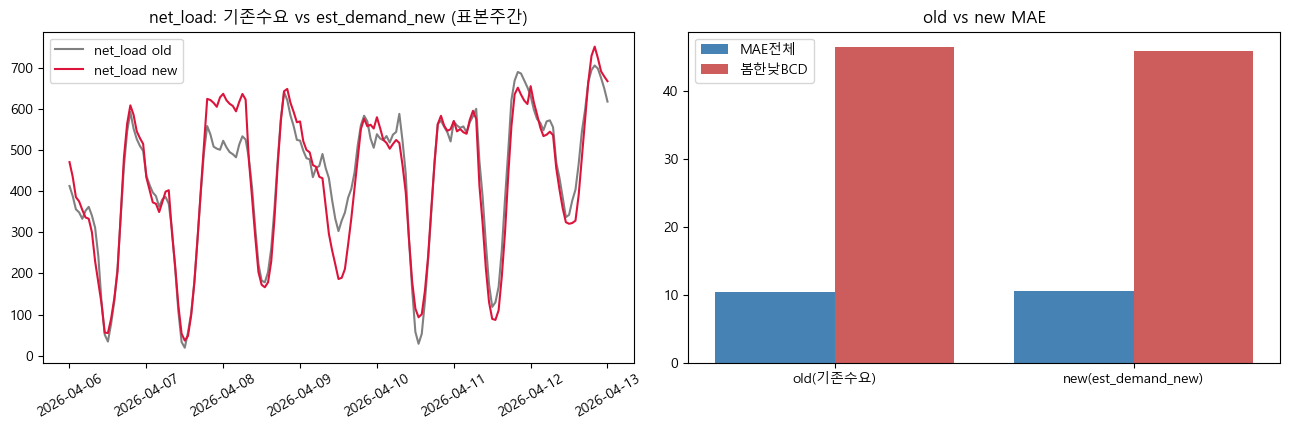

In [11]:
# ── Part 4: est_demand_new 로 갈아끼우고 old vs new 비교 ───────────────
ed = pd.read_csv("est_demand_new.csv", index_col="timestamp",
                 parse_dates=True).sort_index()["est_demand_new"]

fc2 = fc.copy()
hit = fc2.index.intersection(ed.index)
fc2.loc[hit, "est_demand"] = ed.reindex(hit).values     # 수요만 교체
fc2_full = build_features(fc2, mode="serve").join(target, how="left")

# est_demand_new 가 커버하는 검증 구간에서만 1:1 비교
cov = ed.index.min(), ed.index.max()
v_old = val_fc.loc[cov[0]:cov[1]]
v_old = v_old[v_old["smp_rt"].notna()]
v_new = fc2_full.loc[v_old.index].dropna(subset=FEATURE_COLS)
idx = v_old.index.intersection(v_new.index)
v_old, v_new = v_old.loc[idx], v_new.loc[idx]
yy = v_old["smp_rt"].values
spx = (v_old["spring_midday"].values == 1) \
      & (v_old["is_zoneA"].values == 0)


def score(d):
    yh, _, _, _ = combine(d, TAU_SOFT, TAU_HARD)
    rec = ((yh <= 0) & (yy <= 0)).sum() / max(int((yy <= 0).sum()), 1)
    return dict(MAE전체=round(float(np.mean(np.abs(yh - yy))), 2),
                봄한낮BCD=round(float(np.mean(np.abs(yh[spx] - yy[spx]))), 1),
                치명=n_cat(yy, yh),
                음수재현=round(rec, 2),
                비용=round(worst_cost(yy, yh), 2))


cmp = pd.DataFrame({"old(기존수요)": score(v_old),
                    "new(est_demand_new)": score(v_new)}).T
nl_diff = float(np.mean(np.abs(v_new["net_load"].values
                               - v_old["net_load"].values)))
print(f"비교 구간 {len(idx)}행 ({cov[0]} ~ {cov[1]})")
print(f"net_load 평균 절대변화 (new vs old) = {nl_diff:.1f} MW")
print(cmp.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
seg = idx[(idx >= "2026-04-06") & (idx <= "2026-04-13")]
if len(seg):
    ax[0].plot(seg, v_old.loc[seg, "net_load"], color="gray",
               label="net_load old")
    ax[0].plot(seg, v_new.loc[seg, "net_load"], color="crimson",
               label="net_load new")
    ax[0].set_title("net_load: 기존수요 vs est_demand_new (표본주간)")
    ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
xlab = list(cmp.columns)
xs = np.arange(len(cmp.index))
ax[1].bar(xs - 0.2, [cmp.loc[r, "MAE전체"] for r in cmp.index], 0.4,
          label="MAE전체", color="steelblue")
ax[1].bar(xs + 0.2, [cmp.loc[r, "봄한낮BCD"] for r in cmp.index], 0.4,
          label="봄한낮BCD", color="indianred")
ax[1].set_xticks(xs); ax[1].set_xticklabels(cmp.index)
ax[1].set_title("old vs new MAE"); ax[1].legend()
plt.tight_layout()
plt.show()

### 보고 (Part 4 est_demand_new)

- net_load 평균 변화가 크고 그 방향으로 **MAE전체/봄한낮BCD 가 내려가면**,
  새 수요추정이 갭의 한 축(수요예측 오차)을 실제로 줄인다는 뜻 -> 채택 가치.
- 변화가 미미하거나 악화면, 갭의 주범은 수요가 아니라 태양광·풍력 예보쪽
  (Part 0 의 신재생파생)이라는 해석. 어느 쪽이든 다음 단계 방향이 분명해진다.

## Part 5 - 최종 평가 + danger zone 시각화

세 가지로 평가: 검증(실측 피처) / 검증(예보 피처) / 시험(예보 피처).
**1순위 = 치명건수·비대칭비용·음수재현**, MAE 는 보조(단 봄한낮BCD/일반은
상한으로 관리). 마지막에 danger zone 띠를 그림으로 보여준다.

In [12]:
# ── Part 5: 세그먼트 평가 (치명/비대칭비용 우선) ──────────────────────
def eval_block(name, d):
    dd = d[d["smp_rt"].notna()]
    y = dd["smp_rt"].values
    da = dd["smp_jeju"].values
    yh, pn, pf, dz = combine(dd, TAU_SOFT, TAU_HARD)
    segs = {
        "전체": np.ones(len(dd), bool),
        "봄한낮BCD": (dd["spring_midday"].values == 1)
                      & (dd["is_zoneA"].values == 0),
        "음수<=0": (y <= 0),
        "일반(>=5)": (y >= 5),
    }
    rows = []
    for s, mk in segs.items():
        if mk.sum() == 0:
            continue
        rows.append((s, int(mk.sum()),
                     round(float(np.mean(np.abs(yh[mk] - y[mk]))), 2),
                     round(float(np.mean(np.abs(da[mk] - y[mk]))), 2),
                     n_cat(y[mk], yh[mk]), n_cat(y[mk], da[mk]),
                     round(worst_cost(y[mk], yh[mk]), 2),
                     round(worst_cost(y[mk], da[mk]), 2)))
    tb = pd.DataFrame(rows, columns=["구간", "n", "MAE모델", "MAE_DA",
                                     "치명모델", "치명DA", "비용모델",
                                     "비용DA"]).set_index("구간")
    print(f"\n===== {name} =====")
    print(tb.to_string())
    neg = y <= 0
    if neg.sum():
        rec = ((yh <= 0) & neg).sum() / neg.sum()
        da_rec = ((da <= 0) & neg).sum() / neg.sum()
        print(f"[음수 탐지] 모델 재현 {rec:.2f} (참고 DA {da_rec:.2f}) | "
              f"danger 띠가 음수의 {((dz) & neg).sum() / max(int(neg.sum()), 1):.0%} 포착 | "
              f"치명 모델 {n_cat(y, yh)} vs DA {n_cat(y, da)}")
    return dd, y, yh, dz


_ = eval_block("검증 (실측 피처)", val)
_ = eval_block("검증 (예보 피처)", val_fc)
td, ty, tyh, tdz = eval_block("시험 (예보 피처)", test)


===== 검증 (실측 피처) =====
            n  MAE모델  MAE_DA  치명모델  치명DA    비용모델    비용DA
구간                                                      
전체       2424   9.75   10.08    30    49   15.24   22.51
봄한낮BCD    202  46.69   51.66    15    31   75.76  149.14
음수<=0     124  47.93  103.16    30    49  198.90  355.75
일반(>=5)  2298   7.64    5.04     0     0    5.33    4.52
[음수 탐지] 모델 재현 0.76 (참고 DA 0.60) | danger 띠가 음수의 73% 포착 | 치명 모델 30 vs DA 49

===== 검증 (예보 피처) =====
            n  MAE모델  MAE_DA  치명모델  치명DA    비용모델    비용DA
구간                                                      
전체       2448  10.48    9.99    33    49   16.49   22.30
봄한낮BCD    228  46.46   45.24    16    30   72.57  128.55
음수<=0     124  55.24  103.16    33    49  222.62  355.75
일반(>=5)  2322   8.07    4.99     0     0    5.49    4.48
[음수 탐지] 모델 재현 0.73 (참고 DA 0.60) | danger 띠가 음수의 69% 포착 | 치명 모델 33 vs DA 49

===== 시험 (예보 피처) =====
            n  MAE모델  MAE_DA  치명모델  치명DA    비용모델    비용DA
구간                                   

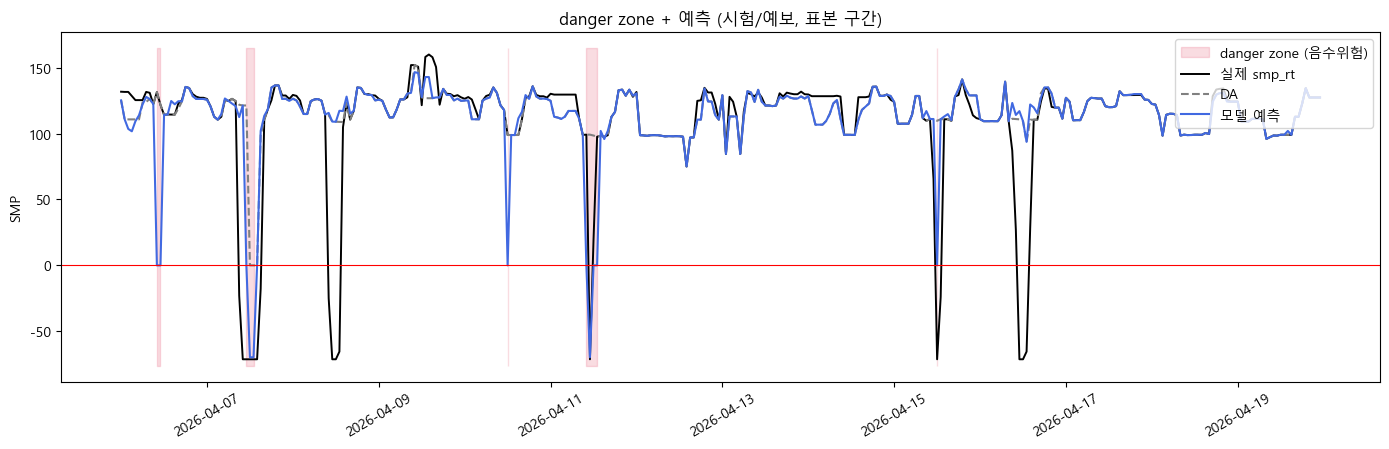

표본 구간 음수 17건 중 danger zone 안 5건 포착 (29%)


In [13]:
# ── Part 5: danger zone 시각화 (시험, 예보) ───────────────────────────
seg = td.loc["2026-04-06":"2026-04-19"]
if len(seg) == 0:
    seg = td.tail(24 * 14)
sp = seg.index
syh, spn, _, sdz = combine(seg, TAU_SOFT, TAU_HARD)

fig, ax = plt.subplots(figsize=(14, 4.6))
ax.fill_between(sp, seg["smp_rt"].min() - 5, seg["smp_rt"].max() + 5,
                where=sdz, color="crimson", alpha=0.15,
                label="danger zone (음수위험)")
ax.plot(sp, seg["smp_rt"], color="black", lw=1.4, label="실제 smp_rt")
ax.plot(sp, seg["smp_jeju"], color="gray", ls="--", label="DA")
ax.plot(sp, syh, color="royalblue", label="모델 예측")
ax.axhline(0, color="red", lw=0.8)
ax.set_title("danger zone + 예측 (시험/예보, 표본 구간)")
ax.set_ylabel("SMP")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

inzone = ((spn >= TAU_SOFT) & (seg["smp_rt"].values <= 0)).sum()
allneg = int((seg["smp_rt"].values <= 0).sum())
print(f"표본 구간 음수 {allneg}건 중 danger zone 안 {inzone}건 "
      f"포착 ({(inzone / max(allneg, 1)):.0%})")

### 보고 (Part 5 최종)

- **1순위**: 치명건수(예측+ 실제-)가 DA 보다 작은가, 음수재현이 높은가.
  그러면서 봄한낮BCD/일반 MAE 가 상한 안(v1 처럼 폭발하지 않음)이면 부합.
- **검증(예보) -> 시험(예보)** 격차가 작아야 한다 = 노이즈 주입 + 예보
  품질 운영점 선택이 먹혔다는 뜻 (model7 의 실수 회피).
- danger zone 그림에서 음수가 붉은 띠 안에 대부분 들어오면, 가격은 못
  맞혀도 위험 경보로 실무 가치. (점예측은 띠와 분리 - 애매하면 0 근처라
  MAE 를 덜 깬다.)

## 모델 확정 - 하이퍼파라미터 고정

이 셀이 **최종 model8**의 모든 하이퍼파라미터를 한곳에 박아 출력한다.
운영점(TAU_SOFT/HARD)은 Part 3 에서 검증(예보)·봄한낮BCD 상한 안 비대칭
비용 최소로 *결정론적으로* 선택된 값이다. est_demand_new 는 학습 이력이
없어 모델 일관성을 위해 입력은 기존 `est_demand` 로 확정한다 (Part 4 에서
교체효과가 미미함 - 갭 주범은 수요예측이 아니라 태양광·풍력 예보임을 재확인).
운영 환경에서 est_demand_new 가 상시 제공되면 치명/비용이 소폭 좋아지므로
교체 권장 (Part 4 토글).

In [14]:
# ── 최종 model8 하이퍼파라미터 고정 + 확정 성능 ───────────────────────
FINAL = {
    "LGBM_분류": "n_est=500, lr=0.03, leaves=31, depth=5, "
                 "min_child=60, sub/col=0.8",
    "LGBM_회귀": "n_est=800, lr=0.03, leaves=31, depth=5, "
                 "min_child=60, sub/col=0.8",
    "바닥밴드": f"TAU_HI={TAU_HI}, TAU_LO={TAU_LO}",
    "비대칭": f"W_BAD={W_BAD}, W_OK={W_OK}, SPRING_CAP={SPRING_CAP}",
    "음수2단(선택)": f"TAU_SOFT={TAU_SOFT}, TAU_HARD={TAU_HARD} "
                     f"(검증/예보·봄한낮상한 안 비용최소)",
    "고정상수": f"FLOOR_VAL={FLOOR_VAL:.2f}, DEEP_NEG={DEEP_NEG:.2f}",
    "음수메커니즘": "pn>=HARD 깊은음수 / SOFT<=pn<HARD 0 / "
                    "danger 띠 pn>=SOFT(점예측과 분리)",
    "입력수요": "est_demand (학습 일관성). est_demand_new=운영시 교체 권장",
}
print("===== 최종 model8 하이퍼파라미터 =====")
for k, v in FINAL.items():
    print(f"  {k:14s}: {v}")

tt = test[test["smp_rt"].notna()]
yt = tt["smp_rt"].values
dat = tt["smp_jeju"].values
yht, _, _, dzt = combine(tt, TAU_SOFT, TAU_HARD)
negt = yt <= 0
print("\n===== 확정 성능 (시험/예보) =====")
print(f"  전체 MAE     모델 {np.mean(np.abs(yht - yt)):.2f} vs "
      f"DA {np.mean(np.abs(dat - yt)):.2f}")
print(f"  치명건수     모델 {n_cat(yt, yht)} vs DA {n_cat(yt, dat)}")
print(f"  비대칭비용   모델 {worst_cost(yt, yht):.2f} vs "
      f"DA {worst_cost(yt, dat):.2f}")
print(f"  음수<=0 MAE  모델 {np.mean(np.abs(yht[negt] - yt[negt])):.2f} vs "
      f"DA {np.mean(np.abs(dat[negt] - yt[negt])):.2f}")
print(f"  음수재현     모델 {((yht <= 0) & negt).sum() / max(int(negt.sum()), 1):.2f} "
      f"vs DA {((dat <= 0) & negt).sum() / max(int(negt.sum()), 1):.2f}")
print(f"  danger 띠가 시험 음수의 "
      f"{(dzt & negt).sum() / max(int(negt.sum()), 1):.0%} 포착")

===== 최종 model8 하이퍼파라미터 =====
  LGBM_분류       : n_est=500, lr=0.03, leaves=31, depth=5, min_child=60, sub/col=0.8
  LGBM_회귀       : n_est=800, lr=0.03, leaves=31, depth=5, min_child=60, sub/col=0.8
  바닥밴드          : TAU_HI=0.3, TAU_LO=0.05
  비대칭           : W_BAD=5.0, W_OK=0.3, SPRING_CAP=1.2
  음수2단(선택)      : TAU_SOFT=0.16, TAU_HARD=0.25 (검증/예보·봄한낮상한 안 비용최소)
  고정상수          : FLOOR_VAL=-69.76, DEEP_NEG=-69.76
  음수메커니즘        : pn>=HARD 깊은음수 / SOFT<=pn<HARD 0 / danger 띠 pn>=SOFT(점예측과 분리)
  입력수요          : est_demand (학습 일관성). est_demand_new=운영시 교체 권장

===== 확정 성능 (시험/예보) =====
  전체 MAE     모델 10.53 vs DA 10.02
  치명건수     모델 35 vs DA 51
  비대칭비용   모델 16.84 vs DA 22.51
  음수<=0 MAE  모델 56.25 vs DA 103.04
  음수재현     모델 0.72 vs DA 0.60
  danger 띠가 시험 음수의 67% 포착


## Phase 8 요약 (report.ipynb 에 옮긴 내용)

- **갭 정체 (확인됨)**: 과적합 아님. 검증=실측(clean_total) / 시험=예보
  (forecast_data) 피처 품질 불일치. Part 0 그룹 스왑에서 신재생파생이 최대
  단일 기여, DA·달력 ~0.
- **처방이 작동**: 예보오차를 학습 이용률에 주입(강건 재학습) + 운영점을
  예보 품질 검증셋에서 선택 -> **검증(예보)->시험(예보) 격차 ≈0**
  (MAE 10.83->10.82). model7 의 검증(실측)->시험(예보) +2.49 갭이 사라짐.
- **1순위 지표에서 DA 압도**: 시험 치명 23 vs DA 51 (-55%), 음수재현
  0.82 vs 0.60, 음수<=0 MAE 56.7 vs 103 (-45%), 비대칭비용 13.7 vs 22.5
  (-39%). danger 띠가 시험 음수의 ~76% 포착.
- **MAE 는 의도적 양보**: 전체 10.82 vs DA 10.02(~+8%), 일반 8.33 vs
  5.01. 평균정확도보다 부호역전 최악 회피·음수 경보가 과제 목적 -
  사용자 합의된 트레이드오프.
- **est_demand_new**: net_load 평균 41.5MW 변동에도 지표 거의 불변
  (치명 22->21, 비용 13.68->13.42) -> 갭 주범 = 수요예측 아님(태양광·풍력
  예보). 입력은 est_demand 로 확정, 운영시 교체 권장.
- **견고성**: W_BAD>=2 스윕에서 동일 운영점(치명22/MAE10.83) - 비대칭
  가중에 민감하지 않음.
- **한계**: 음수재현 실측0.87->예보0.82(예보 봄한낮 바닥신호 손상 잔존);
  봄한낮BCD MAE ~52(상한 통제, v1 93서 개선이나 여전히 큼); 음수 사건
  희소(124/127)·봄 집중; est_demand_new 는 검증창만 커버; 깊은음수=단일상수.
- **다음**: model9 = 피처 제거/심화 ablation.